### Day 15 — Enhancement Results & Detector Training Plan
###Objective
To evaluate the White Balance + CLAHE enhancement baseline, review data-quality observations, define the raw-vs-enhanced comparison metrics, and prepare the YOLO detector training plan.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
DATASET_V1="/content/drive/MyDrive/Dataset_V1"
ENHANCED_DIR="/content/drive/MyDrive/Dataset_V1_Enhanced"
DATASETS=[
    "DIATAquarium.v4i.yolov8",
    "Aquatic Plant.v2i.yolov8",
    "well.v8i.yolov8"
]
print("Dataset V1 exists:",os.path.exists(DATASET_V1))
print("Enhanced Dataset exists:",os.path.exists(ENHANCED_DIR))
for dataset in DATASETS:
    original_path=os.path.join(DATASET_V1,dataset)
    enhanced_path=os.path.join(ENHANCED_DIR,dataset)

    print("\nDataset:",dataset)
    print("Original:",os.path.exists(original_path))
    print("Enhanced:",os.path.exists(enhanced_path))

Dataset V1 exists: True
Enhanced Dataset exists: True

Dataset: DIATAquarium.v4i.yolov8
Original: True
Enhanced: True

Dataset: Aquatic Plant.v2i.yolov8
Original: True
Enhanced: True

Dataset: well.v8i.yolov8
Original: True
Enhanced: True


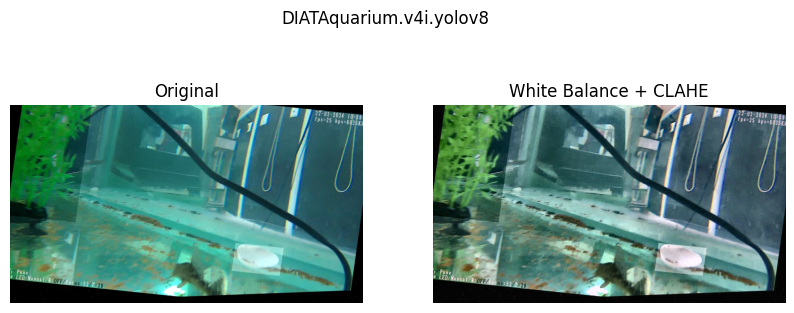

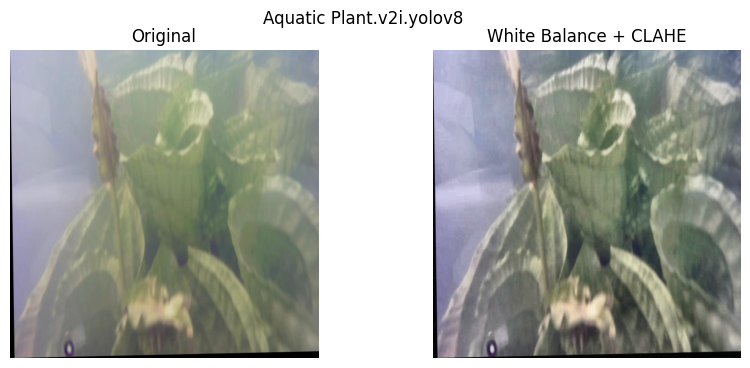

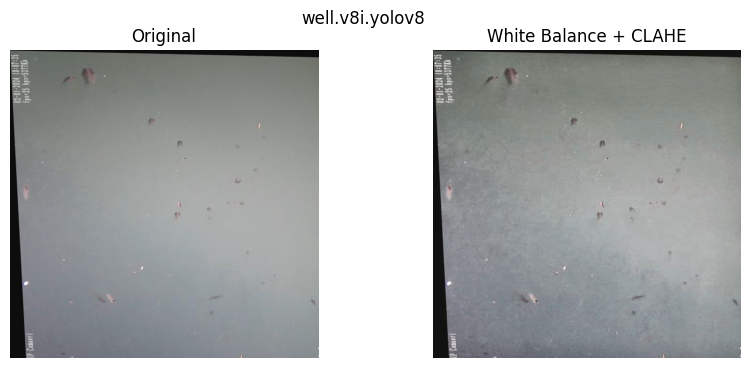

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt
for dataset in DATASETS:
    original_dir=os.path.join(DATASET_V1,dataset,"train","images")
    enhanced_dir=os.path.join(ENHANCED_DIR,dataset,"train","images")

    files=[f for f in os.listdir(original_dir)
           if f.lower().endswith((".jpg",".jpeg",".png"))]
    file=files[5]
    original=cv2.imread(os.path.join(original_dir,file))
    enhanced=cv2.imread(os.path.join(enhanced_dir,file))
    original=cv2.cvtColor(original,cv2.COLOR_BGR2RGB)
    enhanced=cv2.cvtColor(enhanced,cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.imshow(enhanced)
    plt.title("White Balance + CLAHE")
    plt.axis("off")
    plt.suptitle(dataset)
    plt.show()

In [ ]:
import cv2
import os
import numpy as np
import time
for dataset in DATASETS:
    original_dir=os.path.join(DATASET_V1,dataset,"train","images")
    enhanced_dir=os.path.join(ENHANCED_DIR,dataset,"train","images")
    files=[f for f in os.listdir(original_dir)
           if f.lower().endswith((".jpg",".jpeg",".png"))]
    original_brightness=[]
    enhanced_brightness=[]
    original_contrast=[]
    enhanced_contrast=[]
    total=len(files)
    start=time.time()
    print("\nStarting:",dataset)
    print("Total images:",total)
    for i,file in enumerate(files):
        original=cv2.imread(os.path.join(original_dir,file))
        enhanced=cv2.imread(os.path.join(enhanced_dir,file))
        if original is None or enhanced is None:
            print("Skipped:",file)
            continue
        original_gray=cv2.cvtColor(original,cv2.COLOR_BGR2GRAY)
        enhanced_gray=cv2.cvtColor(enhanced,cv2.COLOR_BGR2GRAY)
        original_brightness.append(np.mean(original_gray))
        enhanced_brightness.append(np.mean(enhanced_gray))
        original_contrast.append(np.std(original_gray))
        enhanced_contrast.append(np.std(enhanced_gray))
        if (i+1)%1000==0 or i+1==total:
            elapsed=time.time()-start
            print(f"Processed: {i+1}/{total} | Time: {elapsed:.1f}s")
    print("\nCompleted:",dataset)
    print("Original average brightness:",round(np.mean(original_brightness),2))
    print("Enhanced average brightness:",round(np.mean(enhanced_brightness),2))
    print("Original average contrast:",round(np.mean(original_contrast),2))
    print("Enhanced average contrast:",round(np.mean(enhanced_contrast),2))


Starting: DIATAquarium.v4i.yolov8
Total images: 8121
Processed: 1000/8121 | Time: 1684.9s


KeyboardInterrupt: 

### Here above if we consider all images(13000) it is taking so much time like for 1000 images it is taking 21 min, so i took only 500 images and i comparing then based on that we are going.

In [ ]:
import cv2
import os
import numpy as np
import time
for dataset in DATASETS:
    original_dir=os.path.join(DATASET_V1,dataset,"train","images")
    enhanced_dir=os.path.join(ENHANCED_DIR,dataset,"train","images")
    files=[f for f in os.listdir(original_dir)
           if f.lower().endswith((".jpg",".jpeg",".png"))][:500]
    original_brightness=[]
    enhanced_brightness=[]
    original_contrast=[]
    enhanced_contrast=[]
    start=time.time()
    print("\nDataset:",dataset)
    print("Images analysed:",len(files))
    for i,file in enumerate(files):
        original=cv2.imread(os.path.join(original_dir,file))
        enhanced=cv2.imread(os.path.join(enhanced_dir,file))
        if original is None or enhanced is None:
            continue
        original_gray=cv2.cvtColor(original,cv2.COLOR_BGR2GRAY)
        enhanced_gray=cv2.cvtColor(enhanced,cv2.COLOR_BGR2GRAY)
        original_brightness.append(np.mean(original_gray))
        enhanced_brightness.append(np.mean(enhanced_gray))
        original_contrast.append(np.std(original_gray))
        enhanced_contrast.append(np.std(enhanced_gray))
        if (i+1)%100==0:
            print("Processed:",i+1,"/ 100")
    print("Original average brightness:",round(np.mean(original_brightness),2))
    print("Enhanced average brightness:",round(np.mean(enhanced_brightness),2))
    print("Original average contrast:",round(np.mean(original_contrast),2))
    print("Enhanced average contrast:",round(np.mean(enhanced_contrast),2))
    print("Time:",round(time.time()-start,2),"seconds")


Dataset: DIATAquarium.v4i.yolov8
Images analysed: 500
Processed: 100 / 100
Processed: 200 / 100
Processed: 300 / 100
Processed: 400 / 100
Processed: 500 / 100
Original average brightness: 103.38
Enhanced average brightness: 107.61
Original average contrast: 48.6
Enhanced average contrast: 54.21
Time: 264.91 seconds

Dataset: Aquatic Plant.v2i.yolov8
Images analysed: 500
Processed: 100 / 100
Processed: 200 / 100
Processed: 300 / 100
Processed: 400 / 100
Processed: 500 / 100
Original average brightness: 144.25
Enhanced average brightness: 142.76
Original average contrast: 33.51
Enhanced average contrast: 33.54
Time: 309.49 seconds

Dataset: well.v8i.yolov8
Images analysed: 500
Processed: 100 / 100
Processed: 200 / 100
Processed: 300 / 100
Processed: 400 / 100
Processed: 500 / 100
Original average brightness: 129.96
Enhanced average brightness: 133.0
Original average contrast: 35.53
Enhanced average contrast: 37.09
Time: 405.27 seconds


## Enhancement Baseline Results

White Balance + CLAHE was applied to the training images of all three datasets.

A quantitative comparison was performed using 500 training images from each dataset.

| Dataset | Original Brightness | Enhanced Brightness | Original Contrast | Enhanced Contrast |
|---|---:|---:|---:|---:|
| DIATAquarium | 103.38 | 107.61 | 48.60 | 54.21 |
| Aquatic Plant | 144.25 | 142.76 | 33.51 | 33.54 |
| Well | 129.96 | 133.00 | 35.53 | 37.09 |

### Observation

DIATAquarium showed an increase in both average brightness and contrast after enhancement.

Aquatic Plant showed very little change in average contrast.

Well showed a moderate increase in both average brightness and contrast.

The effect of White Balance + CLAHE therefore differs across datasets.

These statistics are sample-based and were calculated from 500 training images per dataset. They do not by themselves show whether object detection performance improves.

## Detector Training Plan

After the enhancement baseline review,YOLO object detection will be used as the detector.

The detector will be trained separately for each of the three datasets.

Two conditions will be compared:

1. Original Images → YOLO
2. White Balance + CLAHE Enhanced Images → YOLO

The same detector configuration and training conditions will be used for both conditions to make the comparison consistent.

The purpose is to determine whether image enhancement affects underwater object detection performance.

## Raw vs Enhanced Evaluation Metrics

The Original and Enhanced experiments will be compared using the following metrics.

### Detection Metrics

- Precision
- Recall
- mAP@0.5
- mAP@0.5:0.95

### Speed Metric

- Inference time

The detection metrics will be used to determine whether image enhancement affects object detection performance.

Inference time will be recorded to observe whether enhancement introduces additional processing cost.

Image-quality statistics such as brightness and contrast are used to describe the enhancement effect,but they are not treated as detection accuracy.

## Mentor  Corrections


- Original and enhanced images will be compared.
- Detection metrics will include Precision,Recall,mAP@0.5 and mAP@0.5:0.95.
- No video is currently available,so tracking is not included in the current implementation.
- DIATAquarium split handling follows the mentor's earlier guidance.
- we include source containing maximum class and add some other souce we select in such way that selected souces which class have less sample that class in corresponding souce if more then we select that one .